In [2]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
RANDOMSEED=1727

os.environ['PYTHONHASHSEED'] = str(RANDOMSEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:2"

In [3]:
import torch,random
import tensorflow as tf
import numpy as np

tf.config.experimental.enable_op_determinism()
torch.use_deterministic_algorithms(True)

def random_seed(seed=RANDOMSEED, use_cuda=False):
  np.random.seed(seed) # cpu vars
  torch.manual_seed(seed) # cpu vars
  random.seed(seed) # Python
  tf.random.set_seed(seed)
  tf.keras.utils.set_random_seed(seed)
  
  if use_cuda: 
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # gpu vars
    torch.backends.cudnn.deterministic = True  #needed
    torch.backends.cudnn.benchmark = False
    
random_seed(RANDOMSEED)
tf.config.set_visible_devices([], 'GPU')

In [4]:
from pathlib import Path

cred_path = Path('~/.kaggle/access_token').expanduser()
if not cred_path.exists():
  cred_path.parent.mkdir(exist_ok=True)
  cred_path.write_text("KGAT_9f6b15aaf6f7637b8497dfb3c56c079e")
  cred_path.chmod(0o600)

In [5]:
nname = Path('digit-recognizer')

if not iskaggle:
  if not nname.exists():
    import zipfile,kaggle
    kaggle.api.authenticate()
    kaggle.api.competition_download_cli(str(nname))
    zipfile.ZipFile(f'{nname}.zip').extractall(nname)
else:
  # /kaggle/input/competitions/nlp-getting-started/train.csv
  nname = Path(f'/kaggle/input/competitions/{nname}')

# %pip install -q datasets
!dir /o:g /w {nname}
# !ls {nname}

 Volume in drive C is Windows
 Volume Serial Number is 6291-898F

 Directory of c:\Users\longnuub\learning-programming-languages\learning-python\kaggle\digit-recognizer

[..]                    [.]                     test.csv
train.csv               sample_submission.csv   
               3 File(s)    128.134.246 bytes
               2 Dir(s)  135.717.867.520 bytes free


In [6]:
import pandas as pd
train=pd.read_csv(nname/"train.csv")
test=pd.read_csv(nname/"test.csv")

# drop the `id` col for training data ONLY, we need the id for test preds later
# train.drop(columns=["id"],inplace=True)

In [7]:
xtrain=train.copy().drop(columns="label")
xtest=test.copy()
ytrain=train["label"]

xtrain_r=xtrain.values.reshape(xtrain.shape[0],28,28) # (amount of input rows, sizeX, sizeY)
xtrain_r[:2] # first two input images

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(2, 28, 28))

In [8]:
# normalize
xtrain=xtrain.astype("float32") / 255.0
xtest=xtest.astype("float32") / 255.0

# reshape into img
xtrain=xtrain.values.reshape(-1,28,28,1)
xtest=xtest.values.reshape(-1,28,28,1)

# some visualizations

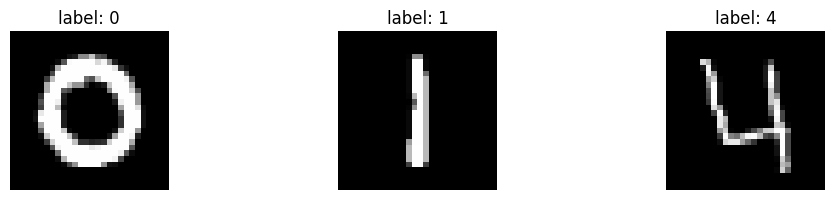

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
for i in range(1,4):
    plt.subplot(3,3,i)
    plt.imshow(xtrain_r[i],cmap="gray")
    plt.title("label: " + str(ytrain[i]))
    plt.axis(False)

# model code

In [10]:
from tensorflow import keras
from keras import layers, optimizers, Sequential, metrics
from keras.initializers import glorot_uniform

init=glorot_uniform(seed=RANDOMSEED)

model=Sequential([
    layers.Input(shape=(28,28,1)),

    # === data augmentation ===
    layers.RandomRotation(factor=0.1,seed=RANDOMSEED),
    layers.RandomTranslation(height_factor=0.03,width_factor=0.03,seed=RANDOMSEED),
    layers.RandomElasticTransform(factor=0.02,scale=0.03,seed=RANDOMSEED),
    layers.RandomGaussianBlur(factor=0.05,seed=RANDOMSEED),
    layers.RandomShear(x_factor=0.03,y_factor=0.03,seed=RANDOMSEED),
    layers.RandomZoom(height_factor=0.08),

    # === neural network layers === 
    # block 1
    layers.Conv2D(32,kernel_size=3,activation="relu",kernel_initializer=init),
    layers.MaxPooling2D(),

    # block 2
    layers.Conv2D(64,kernel_size=3,activation="relu",kernel_initializer=init),
    layers.MaxPooling2D(),

    # # block 3
    # layers.Conv2D(128,kernel_size=3,activation="relu",kernel_initializer=init),
    # layers.MaxPooling2D(),

    # head
    layers.Flatten(),
    # layers.Dense(256,activation="relu",kernel_initializer=init),
    # layers.Dropout(0.3,seed=RANDOMSEED),
    layers.Dense(128,activation="relu",kernel_initializer=init),
    layers.Dropout(0.3,seed=RANDOMSEED),
    layers.Dense(10,activation="softmax",kernel_initializer=init) # output
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_elastic_transform        │ (None, 28, 28, 1)      │             0 │
│ (RandomElasticTransform)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_gaussian_blur            │ (None, 28, 28, 1)      │             0 │
│ (RandomGaussianBlur)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_shear (RandomShear)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
    loss="sparse_categorical_crossentropy",
)

In [13]:
from keras import callbacks

earlystop=callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=True,
    restore_best_weights=True,
)
rlr=callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1,
    min_delta=0.0001,
    min_lr=0.000001,
    cooldown=3,
)

history=model.fit(
    xtrain,ytrain,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[earlystop],
)

Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 46s 45ms/step - accuracy: 0.8474 - loss: 0.4778 - val_accuracy: 0.9687 - val_loss: 0.0906
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 54ms/step - accuracy: 0.9413 - loss: 0.1923 - val_accuracy: 0.9756 - val_loss: 0.0770
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 28s 53ms/step - accuracy: 0.9547 - loss: 0.1472 - val_accuracy: 0.9810 - val_loss: 0.0597
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.9614 - loss: 0.1260 - val_accuracy: 0.9831 - val_loss: 0.0523
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9668 - loss: 0.1053 - val_accuracy: 0.9850 - val_loss: 0.0524
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9699 - loss: 0.0992 - val_accuracy: 0.9843 - val_loss: 0.0575
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.9723 - loss: 0.0923 - val_accuracy: 0.9885 - val_loss: 0.0435
Epoch 8/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 23s 43ms/step - accuracy: 0.9740 - loss: 0.0836 - 

<Axes: >

<Figure size 1200x700 with 0 Axes>

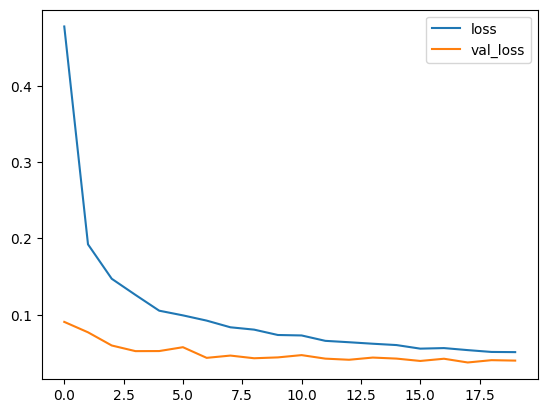

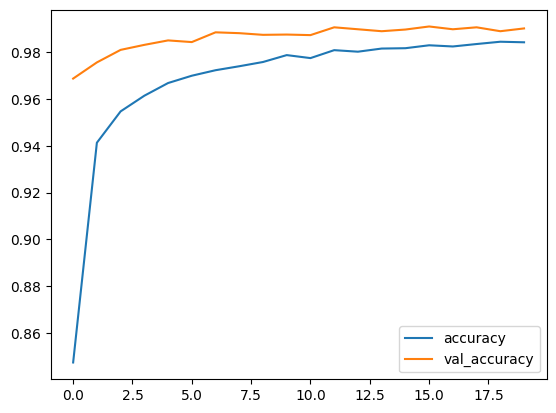

In [14]:
history_frame = pd.DataFrame(history.history)

plt.figure(figsize=(12,7))

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

# prediction

In [15]:
preds=model.predict(xtest)
pred_labels = np.argmax(preds, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


In [16]:
subs_df = pd.DataFrame({
    "ImageId": np.arange(1, len(pred_labels)+1),
    "Label": pred_labels
})

In [17]:
print(subs_df.head())
print(subs_df.shape)

   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      0
4        5      3
(28000, 2)


In [18]:
subs_df.to_csv("submission.csv", index=False)

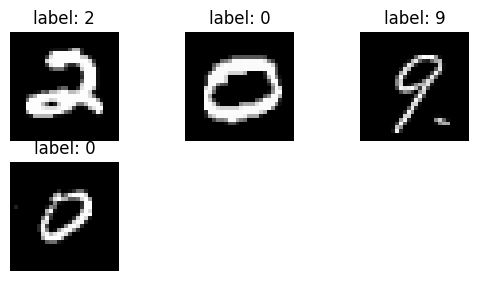

In [19]:
for i in range(0,4):
    plt.subplot(3,3,i+1)
    plt.imshow(xtest[i],cmap="gray")
    plt.title("label: " + str(pred_labels[i]))
    plt.axis(False)